# 02 — Constraint Analysis
**DataStorm v7.0 | SkyNet Team**

Goal: Classify every outlet into one of four constraint archetypes to understand latent demand potential.

### Constraint Types:
1.  **Credit-Constrained**: Consistent ordering at the credit limit ceiling.
2.  **Stockout-Constrained**: Sudden drops to zero mid-month, followed by recovery.
3.  **Delivery-Capped**: Orders always arrive on the same day, same quantity.
4.  **Genuinely Low-Demand**: Stable, low, consistent volumes with no constraint signals.

In [15]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

GOLD_DIR = ROOT / 'data' / 'gold'
REPORTS  = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
print('Setup complete')

Setup complete


## 1. Load Data

In [16]:
df = pd.read_csv(GOLD_DIR / 'model_input_final.csv')
print('Data loaded:', df.shape)

Data loaded: (10492, 50)


## 2. Rule-Based Classification

In [17]:
# Calculate thresholds based on quantiles to ensure data-driven classification
credit_threshold = df['credit_limit_hit_rate'].quantile(0.9)   # Top 10% most hit
cv_threshold     = df['cv_volume'].quantile(0.2)             # Bottom 20% most stable
volume_threshold = df['mean_monthly_volume'].quantile(0.7)    # Top 30% by volume

def classify_outlet(row):
    # 1. Credit-Constrained Signal (High hit rate is the strongest ceiling signal)
    if row['credit_limit_hit_rate'] > credit_threshold and row['credit_limit_hit_rate'] > 0:
        return 'Credit-Constrained'
    
    # 2. Delivery-Capped Signal (Stable + High Volume => hitting a capacity ceiling)
    if row['cv_volume'] < cv_threshold and row['mean_monthly_volume'] > volume_threshold:
        return 'Delivery-Capped'

    # 3. Stockout-Constrained Signal (Gaps in ordering or zero months)
    if row['stockout_flag'] == 1:
        return 'Stockout-Constrained'
    
    # 4. Genuinely Low-Demand
    return 'Genuinely Low-Demand'

df['constraint_type'] = df.apply(classify_outlet, axis=1)
print("Constraint Distribution:")
print(df['constraint_type'].value_counts())
print("\nPercentage:")
print(df['constraint_type'].value_counts(normalize=True) * 100)

Constraint Distribution:
constraint_type
Stockout-Constrained    7727
Delivery-Capped         1882
Credit-Constrained       882
Genuinely Low-Demand       1
Name: count, dtype: int64

Percentage:
constraint_type
Stockout-Constrained    73.646588
Delivery-Capped         17.937476
Credit-Constrained       8.406405
Genuinely Low-Demand     0.009531
Name: proportion, dtype: float64


## 3. Define Uplift Priors (Uncapping Factors)

In [18]:
# Multipliers to estimate 'true' potential from observed volume
UPLIFT_MAP = {
    'Credit-Constrained': 1.5,   # Assume 50% latent demand is suppressed
    'Stockout-Constrained': 1.2, # Assume 20% lost due to stockouts
    'Delivery-Capped': 1.1,      # Assume 10% lost due to capacity
    'Genuinely Low-Demand': 1.0  # Observed is the truth
}

df['uplift_prior'] = df['constraint_type'].map(UPLIFT_MAP)
print('Uplift priors applied')

Uplift priors applied


## 4. Peer-Group Benchmarking (Sanity Check)

In [19]:
# Peer group based on Outlet Type (One-hot cols reconstructed)
type_cols = [c for c in df.columns if 'Outlet_Type_' in c]
df['outlet_type_label'] = df[type_cols].idxmax(axis=1)

# Calculate 90th percentile for each group
p90_benchmarks = df.groupby('outlet_type_label')['mean_monthly_volume'].quantile(0.9)
df['peer_p90_volume'] = df['outlet_type_label'].map(p90_benchmarks)

print('Peer benchmarks calculated')

Peer benchmarks calculated


## 5. Visualise Constraints

C:\Users\User\AppData\Local\Temp\ipykernel_22408\3598469002.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='constraint_type', palette='viridis')


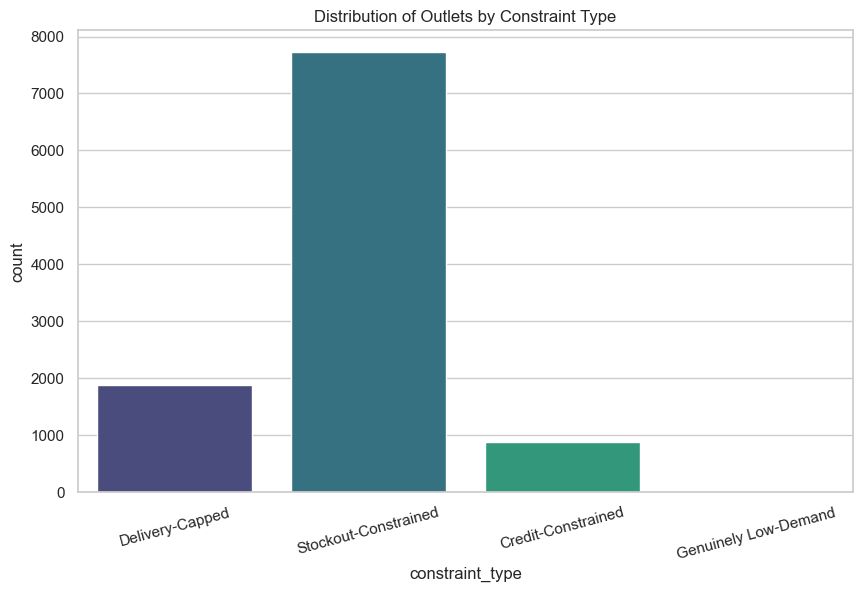

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='constraint_type', palette='viridis')
plt.title('Distribution of Outlets by Constraint Type')
plt.xticks(rotation=15)
plt.savefig(REPORTS / 'constraint_distribution.png')
plt.show()

## 6. Save Enriched Features

In [21]:
df.to_csv(GOLD_DIR / 'outlet_features_with_constraints.csv', index=False)
print('Saved constraint-enriched features to gold layer')

Saved constraint-enriched features to gold layer
